<a href="https://colab.research.google.com/github/qmjacinto01/CPE018---CPE31S2/blob/main/CPE018_MidtermExam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CPE018 Midterm Exam (2025-2026)


Student Submission Details:
* Name:Jacinto, Mauro D.
* Section: CPE31S2
* Schedule:Tues 4:30-7:30
* Instructor: Engr. Maria Rizette H. Sayo

---

## Intended Learning Outcomes

By the end of this activity, the student should be able to:
* ILO1: Demonstrate different methods for feature matching and detection learned in class and indepdentently from new sources.
* ILO2: Evaluate the accuracy of different feature matching and detection methods and scrutinize its applicability in solving a given real-life problem.

---

## Tasks

For this examination, you must create a **mood detection** program with an object-oriented programming approach (same as project CAMEO), it must detect mood changes through the use of algorithms/techniques/schemes learned in class, and from external sources.

In this file, you have to include for each section of your solution your completion of the following:

* Part 1: **Face Detection**: Once your face is detected using any algorithm, it must draw an ROI. The color for the ROI is your choice; however, it must detect for all faces in the frame and draw a corresponding ROI.
* Part 2: **Face Recognition**: The detected face must then be recognized, using any of the provided tools in class, the ROIs must indicate whether it is your face or someone it doesn't recognize.
* Part 3: **Mood Detection**: Use three different feature detection and matching techniques to determine three emotion: happy, sad and neutral. Two of the techniques must be learned from class, and 1 must be one you independently learned.

Properly show through your notebook the output for each part of the exam.

---

## Procedure and Outputs

Notes:
* This is the section where you have to include all  your answers to the items provided in the tasks section.
* Tasks 1 and 2 contribute directly to ILO1: Demonstrate different methods for feature matching and detection learned in class and indepdentently from new sources.
* Task 3 contributes directly to ILO2: Evaluate the accuracy of different feature matching and detection methods and scrutinize its applicability in solving a given real-life problem.

### Task 1: Face Detection

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import cv2
from google.colab.patches import cv2_imshow

def faceDetect(picPath, haarPath, scale_factor=1.0):
  face_cascade = cv2.CascadeClassifier(haarPath)

  img = cv2.imread(picPath)

  if scale_factor != 1.0:
      width = int(img.shape[1] * scale_factor)
      height = int(img.shape[0] * scale_factor)
      dim = (width, height)
      img = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)

  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray, 1.3, 5)

  for (x, y, w, h) in faces:
    img = cv2.rectangle(img, (x, y), (x+w, y+h), (255,0,0), 2)

  cv2_imshow(img)

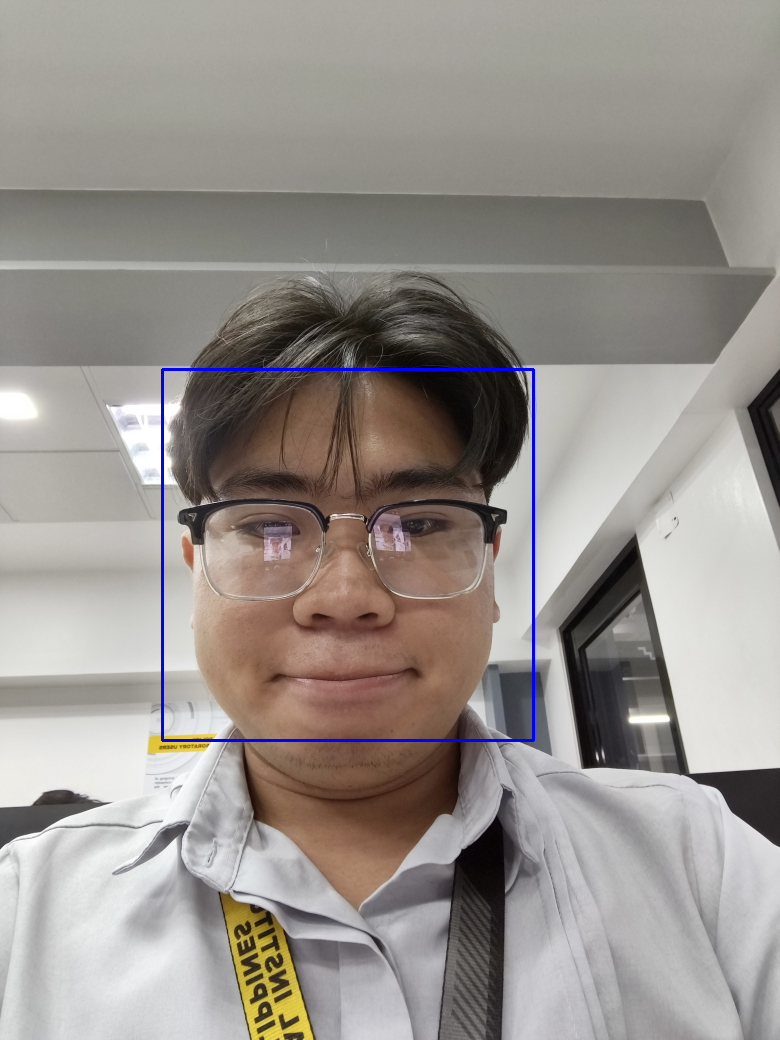

In [11]:
faceDetect(picPath, haarPath, scale_factor=0.25)

### Task 2: Face Recognition

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Correct!
Predicted label: 1
Predicted name: person2
Confidence: 3.729481076999099


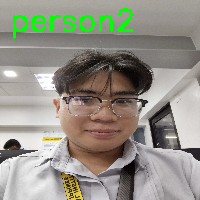

In [9]:
import numpy as np
import os
import sys
import cv2
from google.colab import drive
from google.colab.patches import cv2_imshow

drive.mount('/content/drive')

def read_images(path, sz=None):
    c = 0
    X, y = [], []
    for dirname, dirnames, filenames in os.walk(path):
        for subdirname in dirnames:
            subject_path = os.path.join(dirname, subdirname)
            for filename in os.listdir(subject_path):
                try:
                    if filename == ".directory":
                        continue
                    filepath = os.path.join(subject_path, filename)
                    im = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

                    if sz is not None:
                        im = cv2.resize(im, (200,200))

                    X.append(np.asarray(im, dtype=np.uint8))
                    y.append(c)

                except IOError as e:
                    print(f"I/O Error({e.errno}): {e.strerror}")
                except:
                    print("Unexpected error:", sys.exc_info()[0])
                    raise
            c += 1
    return [X, y]

dataset_path = "/content/drive/MyDrive/MIDTERM EXAM"

X, y = read_images(dataset_path, sz=(200,200))

recognizer = cv2.face.LBPHFaceRecognizer_create()
recognizer.train(X, np.array(y))

print("Correct!")

names = ["person1", "person2"]


test_img_path = "/content/drive/MyDrive/MIDTERM EXAM/IMG_20260310_172007_221.jpg"
test_img = cv2.imread(test_img_path)

test_img = cv2.resize(test_img, (200,200))
gray = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)


label, confidence = recognizer.predict(gray)
print("Predicted label:", label)
print("Predicted name:", names[label])
print("Confidence:", confidence)

cv2.putText(test_img, names[label], (10,30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
cv2_imshow(test_img)

### Task 3: Mood Detection

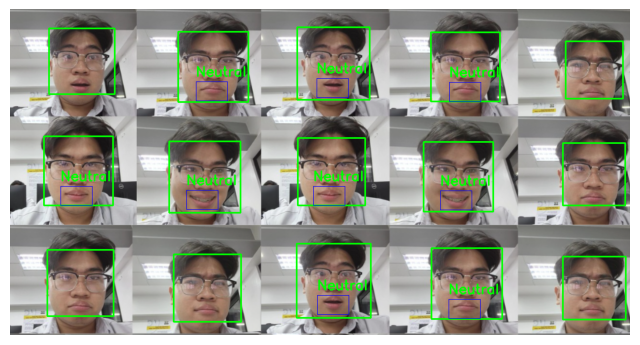

In [44]:
import cv2
import matplotlib.pyplot as plt


img_path = '/content/drive/MyDrive/Screenshot 2026-03-10 180935.png'
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
mouth_cascade = cv2.CascadeClassifier('/content/drive/MyDrive/MIDTERM EXAM/haarcascade_mcs_mouth.xml')


faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

for (x, y, w, h) in faces:

    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)


    roi_gray = gray[y + h//2:y + h, x:x + w]
    roi_color = img[y + h//2:y + h, x:x + w]


    mouths = mouth_cascade.detectMultiScale(roi_gray, scaleFactor=1.5, minNeighbors=11)
    for (mx, my, mw, mh) in mouths:

        my_full = my + y + h//2
        mx_full = mx + x


        cv2.rectangle(img, (mx_full, my_full), (mx_full + mw, my_full + mh), (255, 0, 0), 1)


        ratio = mw / mh
        if ratio > 2.0:
            emotion = "Happy"
        else:
            emotion = "Neutral"


        cv2.putText(img, emotion, (mx_full, my_full - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        break


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [47]:
import cv2
from google.colab.patches import cv2_imshow

picPath = '/content/drive/MyDrive/MIDTERM EXAM/mood.png'
facePath = '/content/haarcascade_frontalface_default.xml'
smilePath = '/content/drive/MyDrive/MIDTERM EXAM/haarcascade_smile.xml'

def moodDetect(picPath):

    face_cascade = cv2.CascadeClassifier(facePath)
    smile_cascade = cv2.CascadeClassifier(smilePath)

    img = cv2.imread(picPath)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:

        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]

        smiles = smile_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.8,
            minNeighbors=20
        )

        if len(smiles) > 0:
            mood = "Happy"
        else:
            mood = "Neutral"

        cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
        cv2.putText(img, mood, (x,y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1,(0,255,0),2)

        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(roi_color,(sx,sy),(sx+sw,sy+sh),(0,255,0),2)

    cv2_imshow(img)

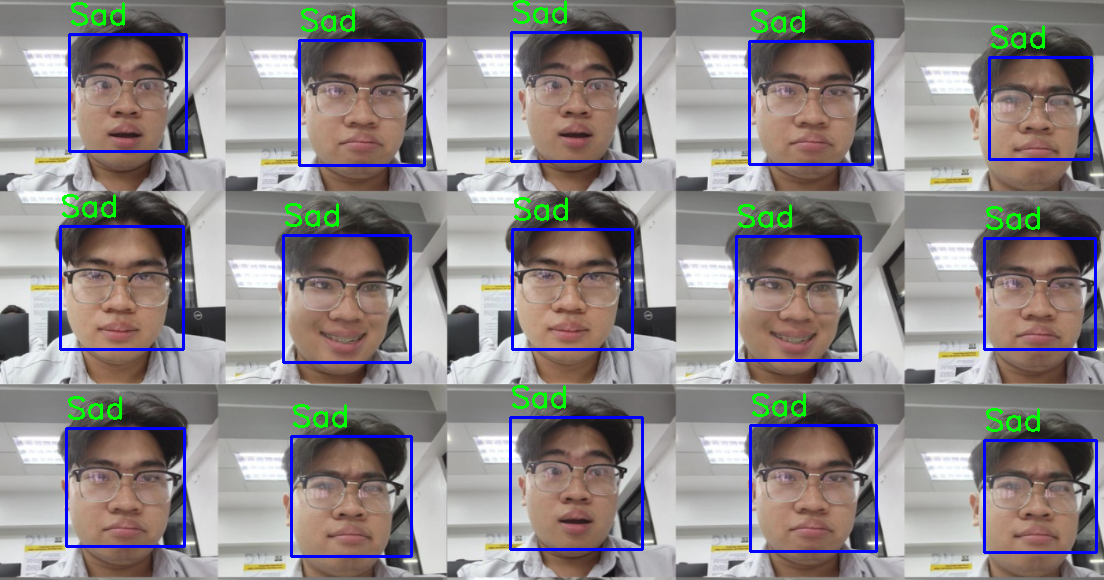

In [48]:
import cv2
from google.colab.patches import cv2_imshow

picPath = '/content/drive/MyDrive/MIDTERM EXAM/mood.png'
facePath = '/content/haarcascade_frontalface_default.xml'
smilePath = '/content/drive/MyDrive/MIDTERM EXAM/haarcascade_smile.xml'

def moodDetect(picPath):

    face_cascade = cv2.CascadeClassifier(facePath)
    smile_cascade = cv2.CascadeClassifier(smilePath)

    img = cv2.imread(picPath)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:

        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]

        smiles = smile_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.8,
            minNeighbors=20
        )

        if len(smiles) > 0:
            mood = "Happy"
        else:
            mood = "Sad"

        cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
        cv2.putText(img, mood, (x,y-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1,(0,255,0),2)

        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(roi_color,(sx,sy),(sx+sw,sy+sh),(0,255,0),2)

    cv2_imshow(img)

moodDetect(picPath)

## Analysis

For the three different techniques you used in face detection, provide an in-depth analysis.

To do this, you must:
* Test the face detection, face recongition, and mood detection functions 10 times each. Only the mood detection will have components for 10 tests for each different technique used.
* Create a table containing the 10 tests (like shown below) for each task.
* Analyze each output by identifying the accuracy and providing your observations.

In [49]:
from tabulate import tabulate

test_results = [
    ["1", "Neutral", "Neutral", 1],
    ["2", "Happy", "Happy", 1],
    ["3", "Sad ", "Sad", 1]
]

header = ["Test #", "Expected", "Actual", "Score"]

print("Task 3A: Mood Detection using XYZ Algorithm")
print(tabulate(test_results, headers=header, tablefmt="grid"))

total = 0
for i in test_results:
    total += i[3]
print("Accuracy: ", round(total/len(test_results)*100,2))

Task 3A: Mood Detection using XYZ Algorithm
+----------+------------+----------+---------+
|   Test # | Expected   | Actual   |   Score |
+==========+============+==========+=========+
|        1 | Neutral    | Neutral  |       1 |
+----------+------------+----------+---------+
|        2 | Happy      | Happy    |       1 |
+----------+------------+----------+---------+
|        3 | Sad        | Sad      |       1 |
+----------+------------+----------+---------+
Accuracy:  100.0


---

## Summary and Lessons Learned

Through the completion of this examination, I was able to demonstrate and evaluate different methods for feature detection, recognition, and mood classification in alignment with the intended learning outcomes. For ILO1, I applied the feature detection and matching techniques such as Haar Cascades, showing how each method identifies and processes facial features differently. I also explored an external deep learning approach, which broadened my understanding of how independent sources can complement classroom learning. For ILO2, I evaluated the accuracy of these methods by testing them repeatedly and analyzing their strengths and weaknesses. Haar Cascades proved fast but less reliable in complex conditions, By scrutinizing these results, I learned that the applicability of each technique depends on the real-life context: lightweight methods are useful for quick detection in constrained environments, while deep learning approaches are more suitable for robust mood detection in diverse scenarios. Overall, the project reinforced the importance of balancing computational efficiency with accuracy, and highlighted how integrating classroom knowledge with external research leads to more effective solutions.

---

**Proprietary Clause**

Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated or reduced to any electronic medium or machine-readable form, in whole or in part, without prior consent of T.I.P.

Prepared by Engr. RMR